In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, f1_score, log_loss, classification_report, confusion_matrix

from pathlib import Path

DATA_DIR = Path("/workspace/data") # Path to dataset
MODEL_DIR = Path("/workspace/models") # Where final models will be saved
CHECKPOINT_DIR = Path("/workspace/checkpoints") # Where epoch checkpoints will go

EPS = np.finfo(float).eps # Machine epsilon to prevent divide by zero

# 14 chest conditions in list form
labels = [
    "Cardiomegaly", 
    "Emphysema", 
    "Effusion", 
    "Hernia", 
    "Infiltration", 
    "Mass", 
    "Nodule", 
    "Atelectasis", 
    "Pneumothorax", 
    "Pleural_Thickening", 
    "Pneumonia", 
    "Fibrosis", 
    "Edema", 
    "Consolidation"
]


2025-11-15 20:09:04.694440: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763237344.919578      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763237344.979845      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
# Access the metadata file which contains finding labels and more infor for each image
csv_path = DATA_DIR / "Data_Entry_2017.csv"
df = pd.read_csv(csv_path) # Convert to a dataframe

# Print and visualize
print("Raw metadata shape:", df.shape)
df.head()


Raw metadata shape: (112120, 12)


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [4]:
# Convert finding labels into 14 binary columns
def process_labels(row: pd.DataFrame):
    finding_labels = row["Finding Labels"].split("|") # Split at "|" as some images have multiple labels
    binary_labels = {label: 0 for label in labels} # Initialize dictionary with all labels set to 0

    # Loop through the findings for each image  
    for f in finding_labels:
        # If the finding is in our dictionary, mark it as 1 which indicates present
        if f in binary_labels:
            binary_labels[f] = 1
    return pd.Series(binary_labels) # Return binary_labels as a series of columns

label_df = df.apply(process_labels, axis=1) # Apply process_labels function to each row in our dataframe
df = pd.concat([df, label_df], axis=1) # Combine label_df with main df column wise

# Rename image index and Patient ID columns for consistency
df.rename(columns={"Image Index": "Image", "Patient ID": "Patient_ID"}, inplace=True)

# Keep only the Image, Patient_ID and all the label columns
columns_to_keep = ['Image', 'Patient_ID'] + labels
df = df[columns_to_keep]

# Print and visualize
print("Shape after binary label columns and rename:", df.shape)
df.head()

Shape after binary label columns and rename: (112120, 16)


,Image,Patient_ID,Cardiomegaly,Emphysema,Effusion,Hernia,Infiltration,Mass,Nodule,Atelectasis,Pneumothorax,Pleural_Thickening,Pneumonia,Fibrosis,Edema,Consolidation
0,00000001_000.png,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
2,00000001_002.png,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,3,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [5]:
# Read list of image filenames used for train/val and test split
train_val_list = (DATA_DIR / "train_val_list.txt").read_text().splitlines()
test_list = (DATA_DIR / "test_list.txt").read_text().splitlines()

# Print how many images are in each split 
print("Train/Val images:", len(train_val_list))
print("Test images:", len(test_list))

# Select rows from df whose "Image" filename appears in the split files
# This filters the main dataframe into two subsets based on split files
train_val_df = df[df["Image"].isin(train_val_list)].copy()
test_df = df[df["Image"].isin(test_list)].copy()

print(train_val_df.shape, test_df.shape)

# Get all unique patients present in the train/val df (to prevent leakage)
unique_patients = train_val_df["Patient_ID"].unique()

# Split the unique patients into train and val splits (80/20 split)
# Using patient lvel split prevents data leakage between train and val since there can be multiple images by a single patient
train_patients, val_patients = train_test_split(
    unique_patients, test_size=0.2, random_state=42, shuffle=True
)

# Build train_df and val_df by selecting rows whose Patient_ID is in each set (reset indexes and discard old ones)
train_df = train_val_df[train_val_df["Patient_ID"].isin(train_patients)].reset_index(drop=True)
val_df = train_val_df[train_val_df["Patient_ID"].isin(val_patients)].reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Print and visualize
print("Train: ", train_df.shape)
print("Val: ", val_df.shape)
print("Test: ", test_df.shape)

train_df.head()


Train/Val images: 86524
Test images: 25596
(86524, 16) (25596, 16)
Train:  (69625, 16)
Val:  (16899, 16)
Test:  (25596, 16)


,Image,Patient_ID,Cardiomegaly,Emphysema,Effusion,Hernia,Infiltration,Mass,Nodule,Atelectasis,Pneumothorax,Pleural_Thickening,Pneumonia,Fibrosis,Edema,Consolidation
0,00000001_000.png,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
2,00000001_002.png,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,00000004_000.png,4,0,0,0,0,0,1,1,0,0,0,0,0,0,0


In [6]:
# Test for leakage
in_train_val = set(train_df["Patient_ID"]).intersection(set(val_df["Patient_ID"]))
in_train_test = set(train_df["Patient_ID"]).intersection(set(test_df["Patient_ID"]))
in_val_test = set(val_df["Patient_ID"]).intersection(set(test_df["Patient_ID"]))
leakage_1 = len(in_train_val) > 0
leakage_2 = len(in_train_test) > 0
leakage_3 = len(in_val_test) > 0
print("Leakage between train and val:", leakage_1)
print("Leakage between train and test: ", leakage_2)
print("Leakage between val and test: ", leakage_3)

Leakage between train and val: False
Leakage between train and test:  False
Leakage between val and test:  False


In [7]:
# Build a mapping from filename to full paths for all PNG images in DATA_DIR
path_list = {}

# Search through DATA_DIR for all pathnames
for path in DATA_DIR.rglob("*.png"): # .rglob recursively find all files ending in .png
    path_list[path.name] = path  # Use file name as key, and the full path as value

# Add a full_path column to each df split by matching image file names to their full paths
for frame in [train_df, val_df, test_df]:
    frame["full_path"] = frame["Image"].map(path_list).astype(str) # As string because that's what the generator accepts

# Check how many image files didn't get matched to a filepath
print("Missing in train: ", train_df["full_path"].isna().sum()) # Use isna() to get boolean list of whether file path exists or not 
print("Missing in val: ", val_df["full_path"].isna().sum())
print("Missing in test: ", test_df["full_path"].isna().sum())


Missing in train:  0
Missing in val:  0
Missing in test:  0


In [8]:
# Train Generator to load images as batches rather than all at once
def get_train_generator(df, filenames, labels, batch_size=16, seed=1, 
                        target_width=320, target_height=320):
    
    print("Creating training generator")
    
    # Normalize images using ImageDataGenerator
    image_generator = ImageDataGenerator(
        samplewise_center=True, # For each image subtract the mean pixel value of that image (removes brightness differences)
        samplewise_std_normalization=True, # For each image divide by its own standard deviation (removes contrast differences)
        horizontal_flip=True  # Random horizontal flips for augmentation
    )

    # Pipeline to read images, put in batches, resize, and normalize using rules from ImageDataGenerator
    generator = image_generator.flow_from_dataframe(
        dataframe=df,
        x_col=filenames,
        y_col=labels,
        class_mode="raw",
        target_size=(target_width, target_height),
        batch_size=batch_size,
        shuffle=True,
        seed=seed
    )

    print("Training generator created")
    
    return generator # Generator batches of (images, labels) from train_df


# Val/Test Generators
def get_test_val_generators(train_df, val_df, test_df, filenames, labels, 
                            sample_size=200, batch_size=16, seed=1, target_width=320, target_height=320):
    
    print("Applying train generator stats to val and test generators")

    # Build a temp generator to get a sample of training images (no normalization or augmentation)
    sample_train_generator = ImageDataGenerator().flow_from_dataframe(
        dataframe=train_df,
        x_col=filenames,
        y_col=labels,
        class_mode="raw",
        target_size=(target_width, target_height),
        batch_size=sample_size, # Reasonable number of images used to get meaningful stats (more then 16, less than all images)
        shuffle=True,
        seed=seed
    )
    
    sample_batch = next(sample_train_generator)[0] # Extract one batch of images (batch_x) and ignore labels

    # Normalization using global statistics to prevent leakage and consistency
    test_val_generator = ImageDataGenerator(
        featurewise_center=True, # For each image subtract the global mean of all training images and not per image
        featurewise_std_normalization=True # For each image, divide by the global standard deviation of the training images
    )

    # Compute global mean and std from the sample batch and apply to every val/test image
    test_val_generator.fit(sample_batch) 

    # Pipeline to read, resize, batch, and normalize images using global normalization
    val_generator = test_val_generator.flow_from_dataframe(
        dataframe=val_df,
        x_col=filenames,
        y_col=labels,
        class_mode="raw",
        target_size=(target_width, target_height),
        batch_size=batch_size,
        shuffle=False,
        seed=seed
    )

    # Pipeline to read, resize, batch, and normalize images using global normalization
    test_generator = test_val_generator.flow_from_dataframe(
        dataframe=test_df,
        x_col=filenames,
        y_col=labels,
        class_mode="raw",
        target_size=(target_width, target_height),
        batch_size=batch_size,
        shuffle=False,
        seed=seed
    )

    print("Applied train set normalization to val and test generators")


    return val_generator, test_generator  # Both produces batches of (images, labels) from val_df and test_df respectively

# Create actual generators from dataframes
train_generator = get_train_generator(train_df, "full_path", labels)
val_generator, test_generator = get_test_val_generators(
    train_df, val_df, test_df, "full_path", labels
)

print("Train, val, and test generators created for model use")


Creating training generator
Found 69625 validated image filenames.
Training generator created
Applying train generator stats to val and test generators
Found 69625 validated image filenames.
Found 16899 validated image filenames.
Found 25596 validated image filenames.
Applied train set normalization to val and test generators
Train, val, and test generators created for model use


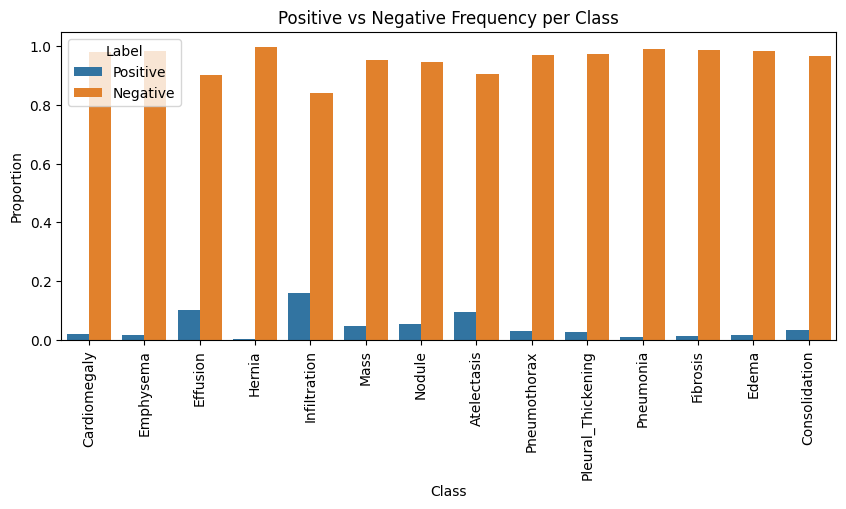

In [9]:
# Compute class frequencies from training generator labels
y_train = train_generator.labels # train_generator.labels return an array (num_samples, num_classes) of 0/1 values

# Frequency for each class
freq_pos = np.mean(y_train, axis=0) # Positive frequency i.e. mean across rows
freq_neg = 1 - freq_pos # Negative frequency i.e. 1 - positive frequency for each class

# Build a larger df for plotting by creating two dfs for pos and neg freqs of each class and then concatenate the two
data = pd.concat([
    pd.DataFrame({"Class": labels, "Label": "Positive", "Value": freq_pos}), # Format: label, Positive, freq_pos value
    pd.DataFrame({"Class": labels, "Label": "Negative", "Value": freq_neg}) # Forma: label, Negative, freq_neg value
])

# Plot positive vs negative frequencies per class
plt.figure(figsize=(10, 4))
plt.xticks(rotation=90)
sns.barplot(x="Class", y="Value", hue="Label", data=data)
plt.title("Positive vs Negative Frequency per Class")
plt.ylabel("Proportion")
plt.show()

In [10]:
# Class weights for positive and negative label to handle imbalance

# pos_weights assigned to rare classes
# Rare classes: freq_pos is small and freq_neg is large so pos examples get higher weight
pos_weights = freq_neg 

# neg_weights assigned to common classes
# Common classes: freq_pos is larger so neg examples get higher weight
neg_weights = freq_pos 

print("pos_weights:", pos_weights)
print("neg_weights:", neg_weights)

pos_weights: [0.98059605 0.98243447 0.89997846 0.99840575 0.83912388 0.95350808
 0.94586715 0.90556553 0.96893357 0.97444883 0.99008977 0.98572352
 0.98371275 0.96634829]
neg_weights: [0.01940395 0.01756553 0.10002154 0.00159425 0.16087612 0.04649192
 0.05413285 0.09443447 0.03106643 0.02555117 0.00991023 0.01427648
 0.01628725 0.03365171]


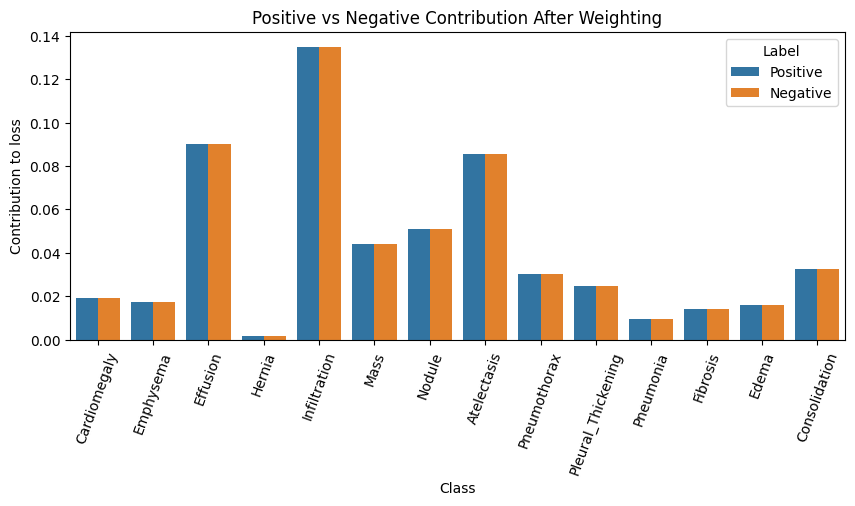

In [11]:
# Check if positive and negative contributions are now balanced

pos_contribution = freq_pos * pos_weights # Positive contribution = (positive frequency) * (positive weight)
neg_contribution = freq_neg * neg_weights # Negative contribution = (negative frequency) * (negative weight)

# Build a larger df for plotting by creating two dfs for pos and neg controbutions of each class and then concatenate the two
data = pd.concat([
    pd.DataFrame({"Class": labels, "Label": "Positive", "Value": pos_contribution}), # Format: label, Positive, pos_contribution value
    pd.DataFrame({"Class": labels, "Label": "Negative", "Value": neg_contribution}) # Format: label, Negative, neg_contribution value
])

# Plot positive vs negative frequencies per class
plt.figure(figsize=(10, 4))
plt.xticks(rotation=70)
sns.barplot(x="Class", y="Value", hue="Label", data=data)
plt.title("Positive vs Negative Contribution After Weighting")
plt.ylabel("Contribution to loss")
plt.show()


In [12]:
# Custom weighted binary cross entropy loss function using class specific positive and negative weights
def get_weighted_loss(pos_weights, neg_weights, epsilon=1e-7):

    # This function returns another function so that Keras can use the final loss function during training
    def weighted_loss(y_true, y_pred):
        
        loss = 0.0 # Initialize loss to zero

        # Loop over each class/label
        for i in range(len(pos_weights)):
            # Extract the true (0/1) and predicted values for class i across the entire batch
            y_t = y_true[:, i] 
            y_p = y_pred[:, i]

            # positive and negative loss terms 
            pos_term = -pos_weights[i] * y_t * K.log(y_p + epsilon) # Positive loss term: like normal BCE multiplied by weight when y_t = 1
            neg_term = -neg_weights[i] * (1.0 - y_t) * K.log(1.0 - y_p + epsilon) # Negative loss term: like normal BCE multiplied by weight when y_t = 0

            loss += K.mean(pos_term + neg_term) # Add the mean loss for this class to the total

        return loss

    return weighted_loss # Return the final loss function for Keras to use

# Create the actual loss function instance using the weights computed
weighted_loss_fucntion = get_weighted_loss(pos_weights, neg_weights)
print("weighted_loss_fucntion created")


weighted_loss_fucntion created


In [ ]:
# Create the DenseNet121

# Base model
base_model = DenseNet121(
    weights="imagenet", # Imagement weights
    include_top=False # Remove DenseNet’s original classification layer
)

x = base_model.output # Output feature maps from DenseNet

x = GlobalAveragePooling2D()(x) # Global average pooling (understand this more)

output = Dense(len(labels), activation="sigmoid")(x) # Final dense layer (sigmoid) that we will add instead of the removed top layer

model = Model(inputs=base_model.input, outputs=output) # Build the complete model using the pieces computed above


# Compile the model using Adam optimizer and the custom weighted loss function
model.compile(optimizer="adam", loss=weighted_loss_fucntion)

model.summary()


I0000 00:00:1763211123.338946      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# File where the best model will be saved.
checkpoint_path = str(MODEL_DIR / "chest_xray_classifier_v1_best.h5")

callbacks = [
    EarlyStopping(
        monitor="val_loss", # Watch validation loss each epoch
        patience=3, # Stop training if val_loss doesn't improve for 3 epochs             
        restore_best_weights=True # After stopping load the best weights seen so far
    ),
    ModelCheckpoint(
        filepath=checkpoint_path, # Save model to this path
        monitor="val_loss", # Save only when val_loss improves
        save_best_only=True, # Prevent saving every epoch—store only the best one
        verbose=1 # Print a message when the model is saved
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,# Reduce learning rate by 50%         
        patience=3, # Wait 3 epochs for improvement
        min_lr=1e-6, # Don't go below this value of learning rate         
        cooldown=1, # Prevents rapid changes by waiting for 1 epoch before making reduction
        verbose=1
    )
]


In [14]:
# Calculate how many batches/epochs are needed to cover the entire dataset

# generator.batch_size gives number of samples in each batch
# generator.n gives total number of images in your a split
train_steps = train_generator.n // train_generator.batch_size  # Number of full batches in train set
val_steps = val_generator.n // val_generator.batch_size # Number of full batches in val set

print("Train steps per epoch: ", train_steps)
print("Val steps per epoch: ", val_steps)

Train steps per epoch:  4351
Val steps per epoch:  1056


In [ ]:
history = model.fit(
    train_generator, # Train gen loads train images as batches
    validation_data=val_generator,# After each epoch evaluate the model on the val set (through val_generator)
    epochs=50, # Train the model (and evaluate) for 3 epochs using the train generator     
    callbacks=callbacks,
    verbose=1
)

# Plot train and val loss over the 3 epochs
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.title("Training & Val Loss")
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1763211188.122804     116 service.cc:148] XLA service 0x7e4c740072d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763211188.123531     116 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1763211196.754306     116 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1763211276.271648     116 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4352/4352 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - loss: 0.7806
Epoch 1: val_loss improved from inf to 0.82735, saving model to /kaggle/working/chest_xray_classifier_v1_best.h5


4352/4352 ━━━━━━━━━━━━━━━━━━━━ 2605s 565ms/step - loss: 0.7806 - val_loss: 0.8274
Epoch 2/15
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - loss: 0.7313
Epoch 2: val_loss improved from 0.82735 to 0.77374, saving model to /kaggle/working/chest_xray_classifier_v1_best.h5


...

4352/4352 ━━━━━━━━━━━━━━━━━━━━ 2001s 460ms/step - loss: 0.7005 - val_loss: 0.7642
Epoch 5/15
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - loss: 0.6836
Epoch 5: val_loss did not improve from 0.76416
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 1914s 440ms/step - loss: 0.6836 - val_loss: 0.8266
Epoch 6/15
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - loss: 0.6761
Epoch 6: val_loss did not improve from 0.76416
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 2038s 468ms/step - loss: 0.6761 - val_loss: 0.7739
Epoch 7/15
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - loss: 0.6661
Epoch 7: val_loss improved from 0.76416 to 0.70215, saving model to /kaggle/working/chest_xray_classifier_v1_best.h5


4352/4352 ━━━━━━━━━━━━━━━━━━━━ 1901s 437ms/step - loss: 0.6661 - val_loss: 0.7021
Epoch 8/15
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - loss: 0.6560
Epoch 8: val_loss did not improve from 0.70215
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 2383s 547ms/step - loss: 0.6560 - val_loss: 0.7169
Epoch 9/15
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - loss: 0.6482
Epoch 9: val_loss did not improve from 0.70215
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 1941s 446ms/step - loss: 0.6482 - val_loss: 0.7079
Epoch 10/15
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - loss: 0.6449
Epoch 10: val_loss improved from 0.70215 to 0.69962, saving model to /kaggle/working/chest_xray_classifier_v1_best.h5


4352/4352 ━━━━━━━━━━━━━━━━━━━━ 1849s 425ms/step - loss: 0.6449 - val_loss: 0.6996
Epoch 11/15
4352/4352 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - loss: 0.6386
Epoch 11: val_loss improved from 0.69962 to 0.69627, saving model to /kaggle/working/chest_xray_classifier_v1_best.h5


4352/4352 ━━━━━━━━━━━━━━━━━━━━ 1976s 454ms/step - loss: 0.6386 - val_loss: 0.6963
Epoch 12/15
 834/4352 ━━━━━━━━━━━━━━━━━━━━ 20:07 343ms/step - loss: 0.6335

KeyboardInterrupt: 

In [ ]:
model.save("/kaggle/working/chest_xray_classifier_v1_final.h5")

CWD: /kaggle/working
['chest_xray_classifier_v1.h5', 'chest_xray_classifier_v1_best.h5', '.virtual_documents']
Working: ['chest_xray_classifier_v1.h5', 'chest_xray_classifier_v1_best.h5', '.virtual_documents']
Input: ['data']
Saved to: /kaggle/working/chest_xray_classifier_v1.h5
Working dir files: ['chest_xray_classifier_v1.h5', 'chest_xray_classifier_v1_best.h5', '.virtual_documents']


In [ ]:
# Load the best trained model from storage
MODEL_PATH = str(MODEL_DIR / "chest_xray_classifier_v1_best.h5")

print("Loading model from:", MODEL_PATH)

model_eval = load_model(MODEL_PATH, compile=False)

print("Model loaded.")


Loading model from: /kaggle/input/chest-xray-classifier-v1-best/tensorflow2/default/1/chest_xray_classifier_v1_best.h5


I0000 00:00:1763238170.539228      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model loaded.


In [ ]:
y_test = test_generator.labels # True labels from the test generator (shape: (num_samples, 14))

test_generator.reset() # Reset generator to start from the first test image

# Predicted probabilities (same shape as y_test)
y_scores = model_eval.predict(test_generator, verbose=1, workers=4, use_multiprocessing=True)

print("y_test shape:", y_test.shape)
print("y_scores shape:", y_scores.shape)


1599/1600 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step

E0000 00:00:1763238808.904163     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763238809.139725     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1600/1600 ━━━━━━━━━━━━━━━━━━━━ 604s 377ms/step
y_test shape: (25596, 14)
y_scores shape: (25596, 14)


In [ ]:
model_name = "chest_xray_classifier_v1"

auc_per_class = {}  # Dictionary to store AUC values for each class
roc_curves = {}     # Dictionary to store (fpr, tpr) pairs for ROC curves

# Loop through each output class
for i, label in enumerate(labels):
    
    y_true = y_test[:, i]   # Ground truth for this class
    y_pred = y_scores[:, i] # Predicted probabilities for this class

    # Compute AUC for this class
    auc = roc_auc_score(y_true, y_pred)
    auc_per_class[label] = float(auc)

    # Compute ROC curve points
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    roc_curves[label] = (fpr, tpr)

    print(f"{label}: AUC = {auc:.3f}")  # Print AUC for this class to 3dp

# Compute macro AUC (mean over classes)
macro_auc = np.mean(list(auc_per_class.values()))
print("\nMacro AUC (mean of classes):", np.round(macro_auc, 3))

# Compute weighted AUC (weighted by number of positives per class)
class_supports = y_test.sum(axis=0)  # Number of positives for each class
weighted_auc = np.average(
    [auc_per_class[label] for label in labels],
    weights=class_supports
)
print("Weighted AUC:", np.round(weighted_auc, 3))


# Binarize predictions using a fixed threshold
threshold = 0.5
y_pred_bin = (y_scores >= threshold).astype(int)

# Subset accuracy: all labels for a sample must match
accuracy = accuracy_score(y_test, np.clip(y_scores, EPS, 1.0 - EPS))

# Macro and weighted F1 scores
macro_f1 = f1_score(y_test, y_pred_bin, average="macro", zero_division=0)
weighted_f1 = f1_score(y_test, y_pred_bin, average="weighted", zero_division=0)

# Log loss
logloss = log_loss(y_test, y_scores)

print("\nOverall metrics:")
print(f"Accuracy (subset): {accuracy:.3f}")
print(f"Macro F1: {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")
print(f"Macro AUC: {macro_auc:.3f}")
print(f"Weighted AUC: {weighted_auc:.3f}")
print(f"Log loss: {logloss:.3f}")

# Per-class precision, recall, F1, support
report = classification_report(
    y_test,
    y_pred_bin,
    target_names=labels,
    output_dict=True,
    zero_division=0
)

per_class_metrics = {
    label: {
        "precision": report[label]["precision"],
        "recall": report[label]["recall"],
        "f1-score": report[label]["f1-score"],
        "support": report[label]["support"],
    }
    for label in labels
}

metrics_dict = {
    "overall": {
        "accuracy": float(accuracy),         
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "macro_auc": float(macro_auc),
        "weighted_auc": float(weighted_auc),
        "log_loss": float(logloss),
    },
    "per_class": per_class_metrics,         
    "per_class_auc": auc_per_class,
}

metrics_path = MODEL_DIR / f"metrics_{model_name}.json"

with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=2)

print(f"\nSaved metrics to: {metrics_path}")


plt.figure(figsize=(10, 8))  # Single plot to visualize all classes

# Plot ROC curve for each class
for label, (fpr, tpr) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_per_class[label]:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guesser (AUC=0.5)")  # Represents random guesser

# Set axis labels and title
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for All Classes")

plt.legend()  # Legend
plt.tight_layout()

roc_path = MODEL_DIR / f"roc_curves_{model_name}.png"
plt.savefig(roc_path)
plt.show()

print(f"Saved ROC curve plot to: {roc_path}")

Cardiomegaly: AUC = 0.797
Emphysema: AUC = 0.722
Effusion: AUC = 0.756
Hernia: AUC = 0.833
Infiltration: AUC = 0.643
Mass: AUC = 0.728
Nodule: AUC = 0.683
Atelectasis: AUC = 0.718
Pneumothorax: AUC = 0.758
Pleural_Thickening: AUC = 0.669
Pneumonia: AUC = 0.615
Fibrosis: AUC = 0.744
Edema: AUC = 0.766
Consolidation: AUC = 0.698

Macro AUC (mean of valid classes): 0.724
